In [1]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import os

# Suppress TensorFlow GPU warnings on Windows
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

tf.get_logger().setLevel("ERROR")

# --- Added Missing Configurations ---
IMG_SIZE = 224
BATCH = 8  # Reduced from 64 to 16 to fix the memory crash
SEED = 42
NUM_CLASSES = 38

In [2]:
import os

# 1. Configuration - Updated for local directory path
dataset_dir = r"C:\Users\Umair Ali\Documents\project\crop-diseases-detection\crop-dataset"

# 3. Universal environment-agnostic paths
train_dir = os.path.join(dataset_dir, "train")
valid_dir = os.path.join(dataset_dir, "valid")

# 4. Generate metadata lists for the train_test_split cell
class_names = sorted([c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))])
paths = []
labels = []
for idx, name in enumerate(class_names):
    class_path = os.path.join(train_dir, name)
    for img_file in os.listdir(class_path):
        paths.append(os.path.join(class_path, img_file))
        labels.append(idx)

print("Train Directory:", train_dir)
print("Valid Directory:", valid_dir)
print(f"Loaded {len(paths)} image paths across {len(class_names)} classes.")

Train Directory: C:\Users\Umair Ali\Documents\project\crop-diseases-detection\crop-dataset\train
Valid Directory: C:\Users\Umair Ali\Documents\project\crop-diseases-detection\crop-dataset\valid
Loaded 70290 image paths across 38 classes.


Number of Classes: 38
Sample Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']

Sample Class Counts:
Apple___Apple_scab → 2016
Apple___Black_rot → 1987
Apple___Cedar_apple_rust → 1760
Apple___healthy → 2008
Blueberry___healthy → 1816


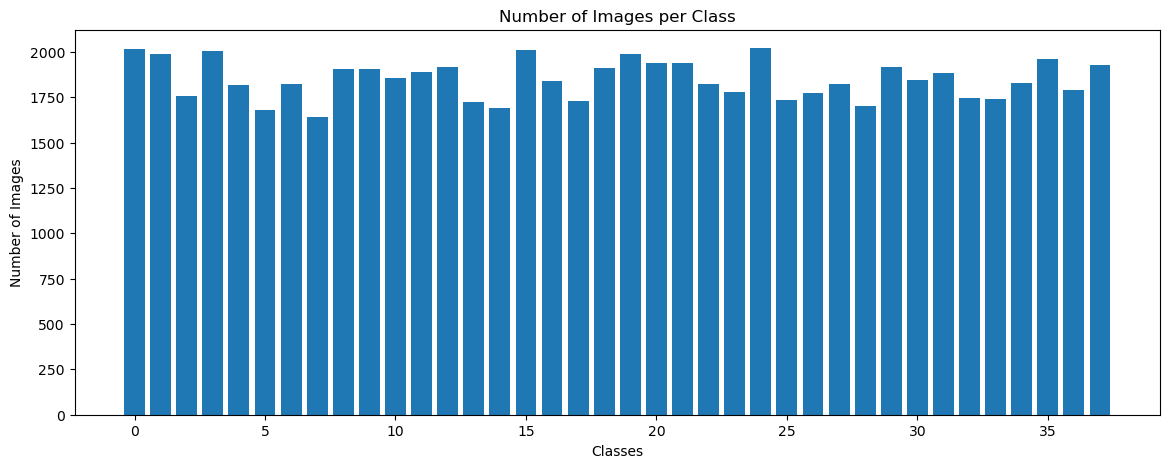

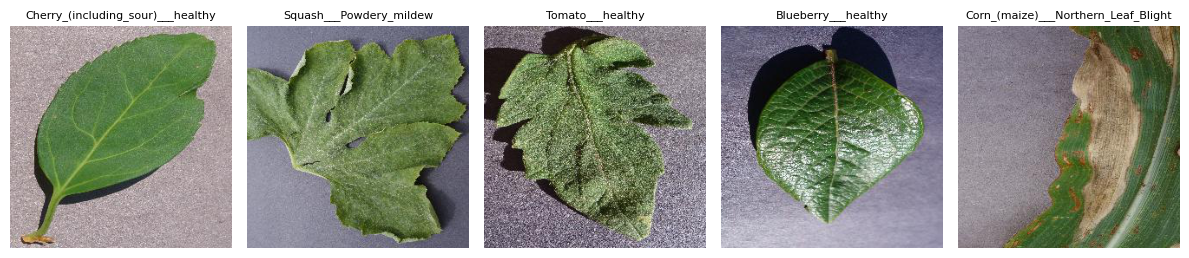

In [3]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# =====================
# 1) Load Classes
# =====================
classes = sorted([c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))])
print("Number of Classes:", len(classes))
print("Sample Classes:", classes[:10])

# =====================
# 2) Count Images per Class
# =====================
class_counts = {}
for c in classes:
    class_path = os.path.join(train_dir, c)
    class_counts[c] = len(os.listdir(class_path))

print("\nSample Class Counts:")
for k in list(class_counts.keys())[:5]:
    print(k, "→", class_counts[k])

# =====================
# 3) Plot Distribution
# =====================
plt.figure(figsize=(14, 5))
plt.bar(range(len(classes)), list(class_counts.values()))
plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

# =====================
# 4) Show Sample Images
# =====================
plt.figure(figsize=(12, 6))
for i in range(5):
    class_name = random.choice(classes)
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = image.load_img(img_path)
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 4. DATA SPLIT (70 / 15 / 15)
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples:    {len(X_test)}")

Training samples:   49203
Validation samples: 10543
Testing samples:    10544


In [5]:
# ============================================================
# 5. DATA PIPELINE + AUGMENTATION
# ============================================================
# We replace the manual feature extraction loop with an end-to-end 
# tf.data pipeline. This processes data in batches, handles data augmentation,
# and trains the model properly instead of extracting flat arrays.

aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, tf.one_hot(label, NUM_CLASSES)

def load_train(path, label):
    img, label = load_image(path, label)
    img = aug(img, training=True)
    return img, label

# Create data loaders using the splits from Cell 4
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(2000).map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("Data pipelines built successfully!")

Data pipelines built successfully!


In [6]:
# ============================================================
# 6. MODEL ARCHITECTURE & COMPILATION
# ============================================================
base = EfficientNetV2B0(include_top=False, weights="imagenet")
base.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)
model = Model(inputs, outputs)

# Loss with label smoothing to prevent overfitting
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Cosine Decay Learning Rate Scheduler
steps_per_epoch = len(X_train) // BATCH
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=steps_per_epoch * 1
)

optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

print("Model architecture compiled and ready in memory!")

Model architecture compiled and ready in memory!


In [7]:
# ============================================================
# 7. TRAIN PHASE 1
# ============================================================
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history1 = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=1, 
    callbacks=callbacks
)

6151/6151 ━━━━━━━━━━━━━━━━━━━━ 2109s 334ms/step - accuracy: 0.8553 - loss: 1.2036 - val_accuracy: 0.9590 - val_loss: 0.8827


In [8]:
# ============================================================
# 8. FINE TUNING (PARTIAL BASE ARCHITECTURE UNLOCKED)
# ============================================================
# Now that the top classification head is trained, we unfreeze 
# the last 10 layers of the EfficientNet base to fine-tune it 
# at a very low learning rate.

base.trainable = True
for layer in base.layers[:-10]:
    layer.trainable = False

# Recompile with a small learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=loss_fn, 
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=1, 
    callbacks=callbacks
)

6151/6151 ━━━━━━━━━━━━━━━━━━━━ 1902s 306ms/step - accuracy: 0.8854 - loss: 1.1387 - val_accuracy: 0.9618 - val_loss: 0.9580


In [12]:
# ============================================================
# 9. EVALUATION FUNCTION (WITH PROGRESS BAR)
# ============================================================
from tqdm.notebook import tqdm

def evaluate(ds):
    print("Generating predictions...")
    preds = model.predict(ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    
    print("Extracting true labels...")
    labels_ds = ds.map(lambda x, y: y, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Using tqdm to show a live visual progress bar for label extraction
    y_true_list = []
    for y in tqdm(labels_ds, desc="Processing Batches"):
        y_true_list.append(y)
        
    y_true_tensor = tf.concat(y_true_list, axis=0)
    y_true = np.argmax(y_true_tensor.numpy(), axis=1)
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    
    print("\nAccuracy:", acc)
    print("F1 Macro:", f1_macro)
    print("F1 Weighted:", f1_weighted)
    print("Precision:", precision)
    print("Recall:", recall)
    
    return y_true, y_pred

Generating predictions...
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 264s 197ms/step
Extracting true labels...


Processing Batches:   0%|          | 0/1318 [00:00<?, ?it/s]


Accuracy: 0.9617755856966708
F1 Macro: 0.9615535624660998
F1 Weighted: 0.961561823556939
Precision: 0.9624340257618599
Recall: 0.9616013961872305
Generating predictions...
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 258s 195ms/step
Extracting true labels...


Processing Batches:   0%|          | 0/1318 [00:00<?, ?it/s]


Accuracy: 0.9638657056145675
F1 Macro: 0.9634420278109692
F1 Weighted: 0.9635272108711685
Precision: 0.9646595386755924
Recall: 0.9636277357552743

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.93      0.95       303
                                 Apple___Black_rot       0.98      0.98      0.98       298
                          Apple___Cedar_apple_rust       1.00      0.98      0.99       264
                                   Apple___healthy       0.92      1.00      0.96       301
                               Blueberry___healthy       0.99      1.00      0.99       272
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.99       252
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       274
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.86      0.91       24

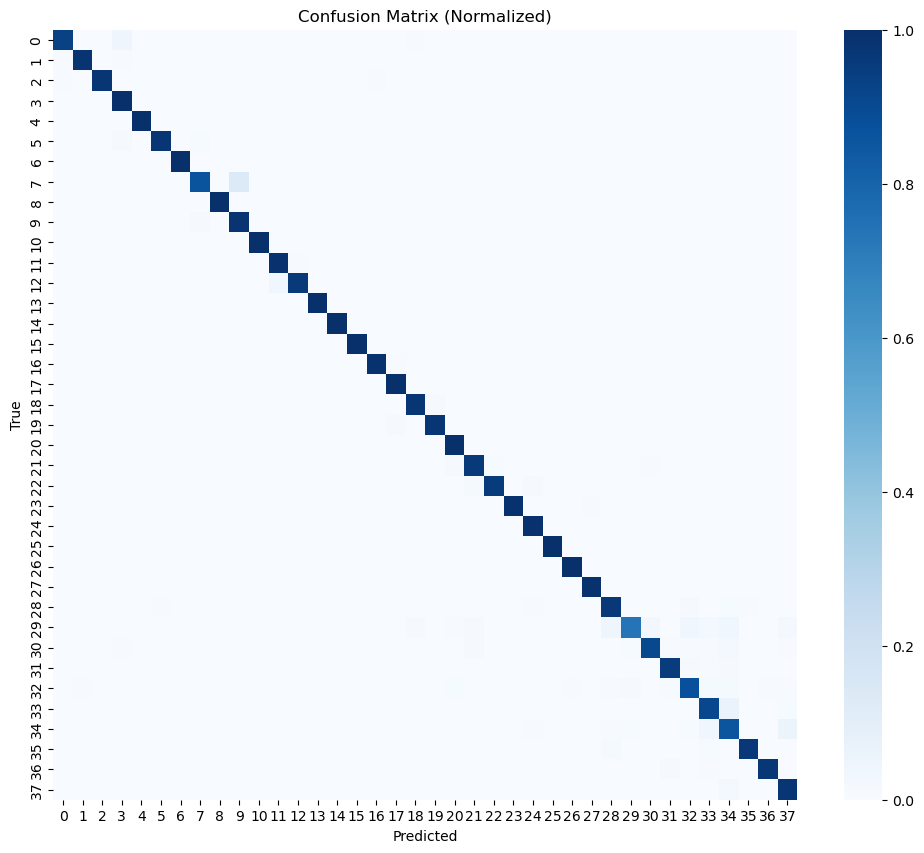

Apple___Apple_scab : 0.934
Apple___Black_rot : 0.9832
Apple___Cedar_apple_rust : 0.9773
Apple___healthy : 0.9967
Blueberry___healthy : 0.9963
Cherry_(including_sour)___Powdery_mildew : 0.9802
Cherry_(including_sour)___healthy : 0.9964
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 0.8618
Corn_(maize)___Common_rust_ : 0.9965
Corn_(maize)___Northern_Leaf_Blight : 0.9825
Corn_(maize)___healthy : 1.0
Grape___Black_rot : 0.9929
Grape___Esca_(Black_Measles) : 0.9618
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1.0
Grape___healthy : 1.0
Orange___Haunglongbing_(Citrus_greening) : 1.0
Peach___Bacterial_spot : 0.9891
Peach___healthy : 0.9961
Pepper,_bell___Bacterial_spot : 0.9791
Pepper,_bell___healthy : 0.9765
Potato___Early_blight : 1.0
Potato___Late_blight : 0.9622
Potato___healthy : 0.9562
Raspberry___healthy : 0.9888
Soybean___healthy : 0.9934
Squash___Powdery_mildew : 1.0
Strawberry___Leaf_scorch : 1.0
Strawberry___healthy : 0.9891
Tomato___Bacterial_spot : 0.9686
Tomato___Early_blig

In [13]:
# ============================================================
# 10. VALIDATION + TEST
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


val_true, val_pred   = evaluate(val_ds)
test_true, test_pred = evaluate(test_ds)

print("\nClassification Report:\n")
print(classification_report(test_true, test_pred, target_names=class_names))

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(test_true, test_pred)
cm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()

# ============================================================
# 12. PER CLASS ACCURACY
# ============================================================
cm_raw = confusion_matrix(test_true, test_pred)
per_class = cm_raw.diagonal() / cm_raw.sum(axis=1)

for i, acc in enumerate(per_class):
    print(class_names[i], ":", round(acc, 4))

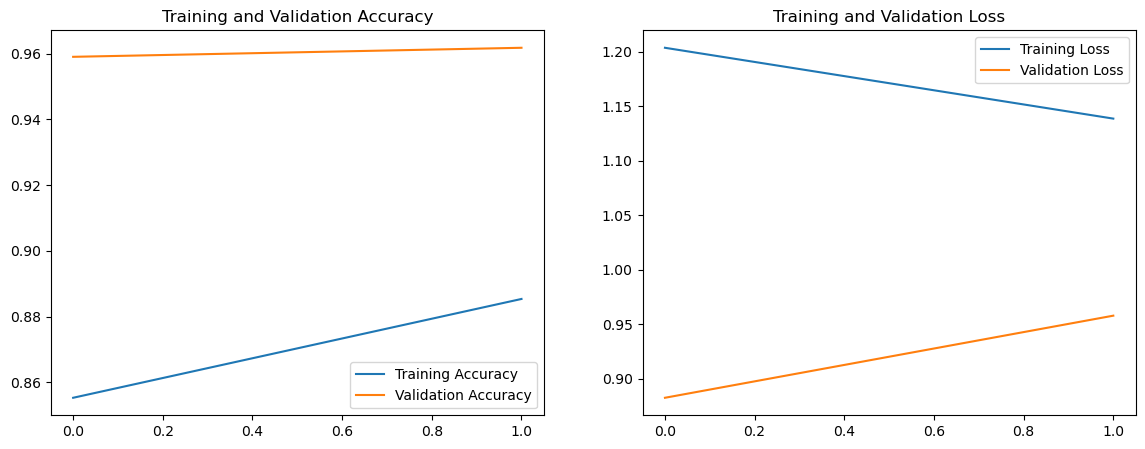

In [15]:
# ============================================================
# 13. PLOT TRAINING HISTORY (OPTIONAL BUT RECOMMENDED)
# ============================================================
# Combine training histories from Phase 1 and Phase 2 to visualize performance
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1) # FIXED: Changed from i + 1 to 1
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


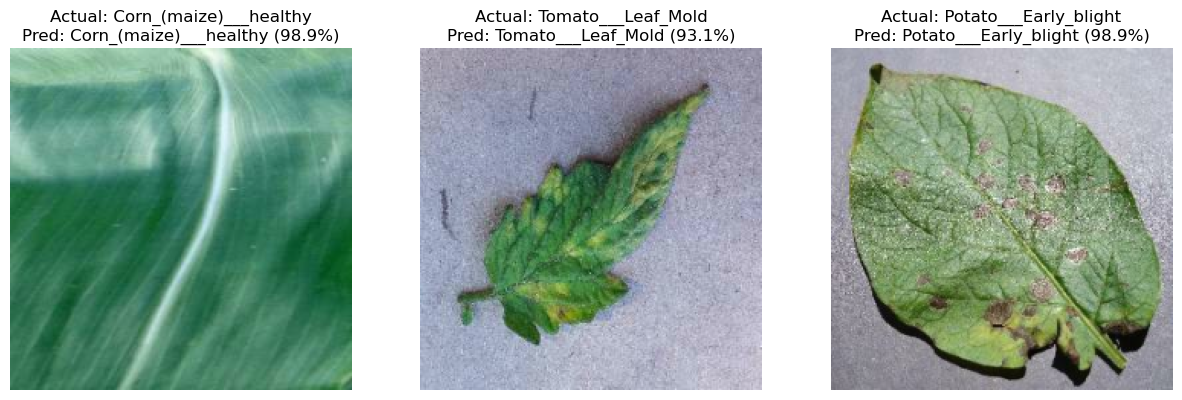

In [16]:
# ============================================================
# 14. PREDICT INDIVIDUAL SAMPLES (IN-MEMORY WORKFLOW)
# ============================================================
# Instead of loading local file paths from Kaggle, we pull a batch 
# from your test dataset to demonstrate real-time model predictions.

# Take 1 batch from the test dataset
for images, labels in test_ds.take(1):
    # Predict the whole batch
    predictions = model.predict(images)
    
    # Plot the first 3 images with their actual and predicted labels
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        
        # Display image (convert back to 0-1 range if necessary)
        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)
        
        actual_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])
        confidence = predictions[i][pred_idx] * 100
        
        plt.title(f"Actual: {class_names[actual_idx]}\nPred: {class_names[pred_idx]} ({confidence:.1f}%)")
        plt.axis("off")
    plt.show()

In [17]:
# ============================================================
# 15. CUSTOM IMAGE PREDICTION FUNCTION (IN-MEMORY WORKFLOW)
# ============================================================
# Instead of hardcoded Kaggle paths, this function downloads an 
# image URL directly or processes a local path to run single-image inferences.

def predict_external_image(img_path):
    print("Running prediction...")
    try:
        # Load and preprocess image
        img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        
        # Predict class
        pred = model.predict(img_array, verbose=0)
        class_index = np.argmax(pred)
        confidence = float(np.max(pred)) * 100
        
        # Display results
        plt.imshow(img)
        plt.title(f"Predicted Class: {class_names[class_index]}\nConfidence: {confidence:.2f}%")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Error loading image: {e}")

print("Prediction function created successfully!")

Prediction function created successfully!


Running prediction...


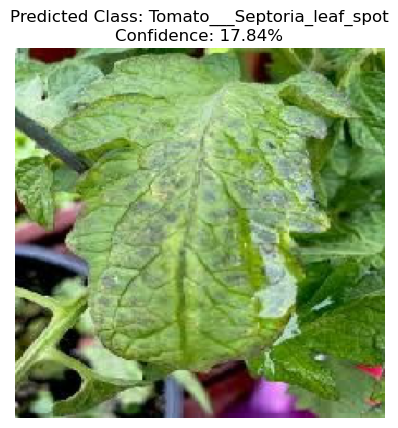

In [20]:
predict_external_image(r"C:\Users\Umair Ali\Documents\project\crop-diseases-detection\crop-dataset\sample-tomato-leaf.jpg")